# 17장 실습 — 실패 유형 분류학

16장의 표는 「나빴다」까지 말해 준다. 그 다음이 문제다. 성공률 0.39와 0.11 사이의 차이는 알겠는데, **무엇을 고쳐야 하는가.**

성공률은 한 숫자다. 한 숫자로는 원인을 가리킬 수 없다. 이 노트북은 실패한 에피소드의 궤적을 읽어 **유형을 자동으로 붙이고**, 정책마다 다른 실패 프로필이 나온다는 것을 보인다. 그리고 유형마다 이 책의 어느 장이 답을 갖고 있는지까지 연결한다.

실행 시간은 CPU에서 5분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 환경은 16장 것을 그대로 쓴다

교란 손잡이가 다섯 축으로 붙어 있는 16장의 환경이다. 엔진, 구동, 지연, 관측, 물리다. 여기에 궤적을 기록하는 기능 하나를 더한다 — 실패를 분류하려면 결과가 아니라 **과정**을 봐야 하기 때문이다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="{integ}" cone="{cone}"
          iterations="{iters}"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MU, KV = .60, 120.
NOMINAL = dict(integ="implicitfast", cone="pyramidal", iters=100)
CACHE = {}


def model_of(mu, kv, integ, cone, iters):
    k = (round(mu, 2), round(kv, 0), integ, cone, iters)
    if k not in CACHE:
        CACHE[k] = mujoco.MjModel.from_xml_string(
            XML.format(mu=k[0], kv=k[1], integ=integ, cone=cone,
                       iters=iters))
    return CACHE[k]


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def expert(b, p, g):
    dv = unit(g - b)
    if np.linalg.norm(g - b) < .012:
        return np.zeros(2)
    e = (b - dv * .045) - p
    if np.linalg.norm(e) > .013:
        u = 14. * e
        n = np.linalg.norm(u)
        return u / n * .22 if n > .22 else u
    return dv * .22


class Vec:
    def __init__(self, n, seed=0, mu=MU, kv=KV, lat=0, noise=0.,
                 bias=(0., 0.), quant=0, rate=0., **eng):
        e = dict(NOMINAL, **eng)
        self.m = model_of(mu, kv, e["integ"], e["cone"], e["iters"])
        self.sub = int(round(1 / 20 / self.m.opt.timestep))
        self.n, self.lat, self.noise = n, lat, noise
        self.quant, self.rate = quant, rate
        self.bias = np.asarray(bias)
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.buf = [None] * n
        self.prev = np.zeros((n, 2))
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
        self.buf[i] = [np.zeros(2)] * (self.lat + 1)
        self.prev[i] = 0.

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float) + self.bias
            if self.noise:
                b = b + self.rng.normal(0, self.noise, 2)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def shape(self, i, a):
        # 구동기가 실제로 받는 명령 — 양자화와 변화율 제한
        u = np.clip(a, -1, 1) * AMAX
        if self.quant:
            step = 2 * AMAX / self.quant
            u = np.round(u / step) * step
        if self.rate:
            d = np.clip(u - self.prev[i], -self.rate, self.rate)
            u = self.prev[i] + d
        self.prev[i] = u
        return u

    def step(self, a, keep=None):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            self.buf[i].append(self.shape(i, a[i]))
            d.ctrl[:] = self.buf[i][-1 - self.lat]
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3, **kw):
    torch.manual_seed(seed)
    env = Vec(n, seed, **kw)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


class BCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 2))

    def forward(self, x):
        return self.f(x)


def collect_bc(n_ep=200, seed=1, **kw):
    env = Vec(8, seed, **kw)
    X, Y = [], []
    for _ in range(n_ep * EP // 8):
        o = env.obs()
        acts = []
        for i, d in enumerate(env.d):
            b = np.asarray(d.qpos[0:2], float)
            acts.append(expert(b, np.asarray(d.qpos[7:9], float),
                               env.g[i]) / AMAX)
        acts = np.array(acts, np.float32)
        X.append(o)
        Y.append(acts)
        env.step(acts)
    return np.concatenate(X), np.concatenate(Y)


def train_bc(X, Y, seed=0, epochs=150):
    torch.manual_seed(seed)
    net = BCNet()
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    X, Y = torch.from_numpy(X), torch.from_numpy(Y)
    n = len(X)
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 256):
            j = idx[k:k + 256]
            loss = ((net(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return net


def score(pol, n=150, seed=999, **kw):
    kind, net = pol
    torch.manual_seed(seed)
    env = Vec(8, seed, **kw)
    got = []
    while len(got) < n:
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            if kind == "rl":
                u = net.dist(o).sample().numpy()
            else:
                u = net(o).numpy()
        got += env.step(u)[2]
    return float(np.mean(got[:n]))

## 궤적을 남기고 유형을 붙인다

에피소드 하나에서 기록할 것은 세 줄이다 — 매 스텝의 **블록–목표 거리**, **밀대–블록 거리**, 그리고 목표 원 안에 있었는지 여부다. 이 셋이면 다섯 유형이 갈린다.

- **F1 도달 실패** — 밀대가 블록에 한 번도 제대로 닿지 않았다
- **F2 방향 오류** — 블록을 밀긴 했는데 목표에서 오히려 멀어졌다
- **F3 미달** — 목표 쪽으로 갔지만 못 미쳤다
- **F4 지나침** — 목표 원에 들어갔다가 나와서 끝났다
- **F5 근처에서 헤맴** — 목표 언저리를 오갔는데 끝내 안에 있지 못했다

분류 규칙은 손으로 적은 것이고, 이 과제에 맞춘 것이다. 중요한 것은 규칙의 정확한 형태가 아니라 **실패를 한 덩어리로 세지 않는다**는 원칙이다.

In [5]:
TOUCH = .05          # 이보다 가까워진 적이 없으면 「닿지 않았다」
NEAR = .06           # 목표 언저리


def episode(pol, rng, **kw):
    # 한 판을 굴리고 궤적을 돌려준다
    kind, net = pol
    env = Vec(1, 0, **kw)
    env.rng = rng
    env.reset(0)
    db, dp, ok = [], [], 0.
    for t in range(EP):
        # 스텝이 끝나면 환경이 스스로 초기화하므로 미리 적는다
        db.append(env.db[0])
        dp.append(env.dp[0])
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            if kind == "rl":
                u = net.dist(o).sample().numpy()
            else:
                u = net(o).numpy()
        sc = env.step(u)[2]
        if sc:
            ok = sc[0]
    db, dp = np.array(db), np.array(dp)
    return db, dp, db < GOAL_R, ok


def classify(db, dp, inside, ok):
    if ok:
        return "성공"
    if dp.min() > TOUCH:
        return "F1 도달 실패"
    if db[-1] > db[0] + .01:
        return "F2 방향 오류"
    if inside.any():
        return "F4 지나침"
    near = db < NEAR
    if near.sum() > 8:
        return "F5 근처에서 헤맴"
    return "F3 미달"


KINDS = ["성공", "F1 도달 실패", "F2 방향 오류", "F3 미달",
         "F4 지나침", "F5 근처에서 헤맴"]


def profile(pol, n=120, seed=999, **kw):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    cnt = {k: 0 for k in KINDS}
    for _ in range(n):
        cnt[classify(*episode(pol, rng, **kw))] += 1
    return {k: v / n for k, v in cnt.items()}

## 후보 넷을 실기 조건에 올린다

16장에서 세운 네 후보를 그대로 쓴다. 조건은 16장의 「실기」 — 아홉 축을 한꺼번에 켠 것이다.

In [6]:
t0 = time.time()
POL = {}
POL["RL 씨앗0"] = ("rl", train_rl(seed=0))
POL["RL 씨앗1"] = ("rl", train_rl(seed=1))
POL["모방"] = ("bc", train_bc(*collect_bc()))
POL["모방+증강"] = ("bc", train_bc(*collect_bc(noise=.003)))
print(f"정책 넷 준비 끝  ({time.time()-t0:.0f}s)")

STAGES = {
    "① 엔진 — 적분기": dict(integ="Euler"),
    "② 엔진 — 마찰 원뿔": dict(cone="elliptic"),
    "③ 엔진 — 솔버 반복": dict(iters=10),
    "④ 구동 — 양자화": dict(quant=16),
    "⑤ 구동 — 변화율 제한": dict(rate=.12),
    "⑥ 지연 1스텝": dict(lat=1),
    "⑦ 관측 잡음 6mm": dict(noise=.006),
    "⑧ 관측 편향 6mm": dict(bias=(.006, -.004)),
    "⑨ 물리 — 마찰 0.8": dict(mu=.80),
}
REAL = {}
for _kw in STAGES.values():
    REAL.update(_kw)

prof = {}
for name, p in POL.items():
    prof[name] = profile(p, **REAL)
    print(f"{name} 분류 끝  ({time.time()-t0:.0f}s)")

print()
hdr = list(POL)
print(pad("유형", 18) + "".join(pad(h, 13, True) for h in hdr))
for k in KINDS:
    print(pad(k, 18)
          + "".join(pad(f"{prof[h][k]:.2f}", 13, True)
                      for h in hdr))

정책 넷 준비 끝  (119s)


RL 씨앗0 분류 끝  (122s)


RL 씨앗1 분류 끝  (126s)


모방 분류 끝  (128s)


모방+증강 분류 끝  (131s)

유형                   RL 씨앗0     RL 씨앗1         모방    모방+증강
성공                       0.29         0.04         0.67         0.09
F1 도달 실패               0.00         0.00         0.00         0.00
F2 방향 오류               0.00         0.03         0.00         0.00
F3 미달                    0.63         0.88         0.01         0.69
F4 지나침                  0.00         0.04         0.05         0.04
F5 근처에서 헤맴           0.07         0.01         0.28         0.17


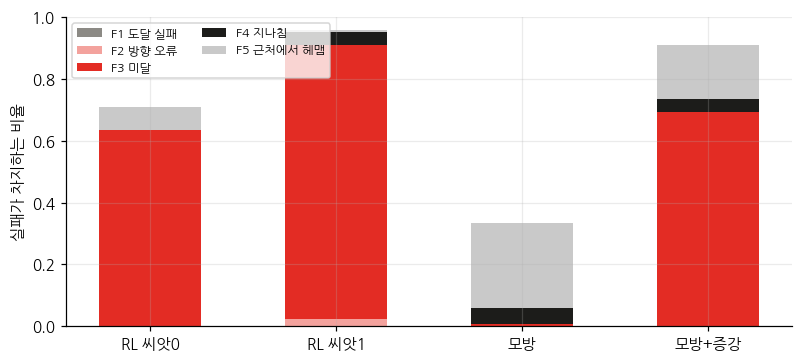

In [7]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
cols = (GREY, PINK, RED, INK, "#C9C9C9")
bottom = np.zeros(len(hdr))
for k, c in zip(KINDS[1:], cols):
    v = np.array([prof[h][k] for h in hdr])
    ax.bar(hdr, v, bottom=bottom, color=c, label=k, width=.55)
    bottom += v
ax.set_ylabel("실패가 차지하는 비율")
ax.set_ylim(0, 1)
ax.legend(fontsize=8, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()

## 유형마다 약이 다르다

앞의 열네 장이 만든 도구들을 유형에 붙여 보면 이렇게 된다.

> **F1 도달 실패** — 밀대가 블록까지 못 간다. 9장의 접근 항이 빠졌거나 너무 약한 경우가 흔하다. 관측이 크게 어긋나 블록의 자리를 잘못 알고 있을 수도 있다(11·13장).
> **F2 방향 오류** — 블록의 위치를 잘못 알고 있다는 가장 강한 신호다. 13장의 교정·번역이 첫 번째 의심이고, 12장의 앵커가 두 번째다.
> **F3 미달** — 힘이나 시간이 모자란다. 마찰 추정이 낮은 쪽으로 틀렸을 때 전형적이다(4장). 구동기의 변화율 제한이나 데드존도 여기로 나타난다(5·16장).
> **F4 지나침** — 반대로 과했거나 멈출 타이밍을 놓쳤다. 지연이 첫 번째 의심이다(10·15장).
> **F5 근처에서 헤맴** — 목표 언저리에서 결정을 못 한다. 관측 잡음과 정책의 미세 조정 능력이 부딪히는 자리이고, 성공 판정 반경 자체를 다시 볼 자리이기도 하다.

이 표가 완전한 분류는 아니다. 실제 시스템에서는 파지 실패, 물체를 놓침, 도달 불가능한 자세, 판단 오류처럼 이 과제에 없는 유형이 더 붙는다. 중요한 것은 목록의 길이가 아니라 **로그에서 자동으로 붙일 수 있는 라벨**을 갖는 것이다.

## 어느 축이 어느 유형을 만드나

유형별 프로필의 진짜 쓸모는 **교란과 연결**할 때 나온다. 모방 정책 하나를 붙들고 축을 하나씩 켜서 프로필이 어떻게 바뀌는지 본다.

In [8]:
t0 = time.time()
rows = [("교란 없음", {})]
rows += [(s, kw) for s, kw in STAGES.items()
         if s.startswith(("⑤", "⑥", "⑧", "⑨"))]
out = {}
for name, kw in rows:
    out[name] = profile(POL["모방"], n=80, **kw)

print(pad("조건", 22)
      + "".join(pad(k.split()[0], 10, True) for k in KINDS))
for name, _ in rows:
    print(pad(name, 22)
          + "".join(pad(f"{out[name][k]:.2f}", 10, True)
                    for k in KINDS))
print(f"\n({time.time()-t0:.0f}s)")

조건                        성공        F1        F2        F3        F4        F5
교란 없음                   0.93      0.00      0.00      0.04      0.04      0.00
⑤ 구동 — 변화율 제한        0.62      0.00      0.00      0.16      0.03      0.19
⑥ 지연 1스텝                0.94      0.00      0.00      0.00      0.06      0.00
⑧ 관측 편향 6mm             0.11      0.00      0.00      0.79      0.04      0.06
⑨ 물리 — 마찰 0.8           0.88      0.00      0.00      0.01      0.03      0.09

(7s)


## 정리

**성공률 하나로는 무엇을 고칠지 알 수 없다.** 같은 실패율 안에 서로 다른 병이 섞여 있다.

**실패는 로그에서 자동으로 분류할 수 있다.** 이 과제에서는 블록–목표 거리, 밀대–블록 거리, 목표 원 안에 있었는지 세 줄이면 다섯 유형이 갈렸다.

**정책마다 실패 프로필이 다르다.** 강화학습 정책은 미달로, 모방 정책은 목표 언저리의 헤맴으로 죽었다. 빈 칸도 정보다 — 이 조건에서 도달 실패와 방향 오류는 거의 없었고, 그 두 축에는 예산을 쓸 이유가 없다.

**교란 축과 실패 유형이 대응한다.** 그 대응표가 있으면 실기 로그 한 판에서 얻는 정보가 크게 늘어난다. 다만 대응표는 가설이고, 이 노트북에서도 한 줄이 실험과 어긋나 고쳐야 했다.

**프로필은 절대값이 아니라 비교로 읽는다.** 분류 규칙이 과제마다 다르기 때문이다.

다음 장은 이 책의 마지막 질문을 다룬다. 지금까지 시뮬레이터를 고치고 덮고 채점했는데, 그 시뮬레이터를 **학습된 모델로 대체할 수 있는가.**